# Predicting Refractive Index in the MatBench Dielectric Dataset

This project investigates the prediction of dielectric refractive index using classical machine learning models on the `matbench_dielectric` dataset. The workflow includes dataset loading, target preprocessing, descriptor generation with `matminer`, model comparison, hyperparameter tuning, and final evaluation on a held-out test set.

## Project overview

The goal of this project is to predict the refractive index of dielectric materials from crystal-structure-derived descriptors. This is a typical materials informatics task in AI for Science, where domain-specific features and machine learning models are combined to learn structure–property relationships.

The main stages of the workflow are:

- load the dataset
- inspect and preprocess the target
- generate composition- and structure-based descriptors
- compare baseline and non-linear regression models
- tune the best-performing models
- evaluate performance on a held-out test set

## Imports and setup

This section imports the local project modules and sets up the notebook environment.

In [11]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
# 当前 notebook 在 notebooks/，所以 root 是上一层
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/abelwu/Desktop/Predicting-dielectric-refractive-index-with-machine-learning-main


In [12]:
from src.data import load_raw_dataset, prepare_dataframe
from src.features import featurize_dataframe, build_feature_matrix
from src.train import split_data, get_models, cross_validate_models, tune_models, fit_models
from src.evaluate import (
    plot_target_distribution,
    evaluate_on_test,
    make_prediction_plot,
    save_model_comparison,
)

## Load the dataset

The `matbench_dielectric` dataset is loaded using `matminer`. It contains crystal structures together with the target property used in this study.

In [13]:
df = load_raw_dataset("matbench_dielectric")
df.head()

,structure,n
0,"[[4.29304147 2.4785886 1.07248561] S, [4.2930...",1.752064
1,"[[3.95051434 4.51121437 0.28035002] K, [4.3099...",1.652859
2,"[[-1.78688104 4.79604117 1.53044621] Rb, [-1...",1.867858
3,"[[4.51438064 4.51438064 0. ] Mn, [0.133...",2.676887
4,"[[-4.36731958 6.8886097 0.50929706] Li, [-2...",1.793232


## Target preprocessing

The target variable is inspected and log-transformed. A log transform is used here to reduce skewness and make the regression task more numerically stable.

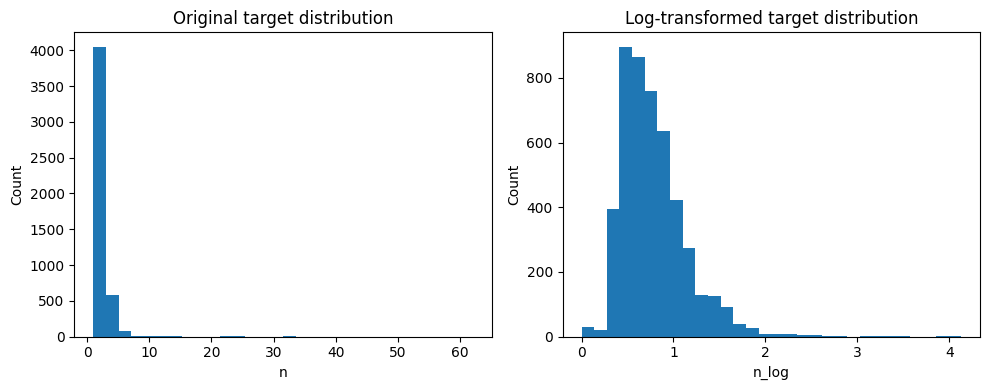

,n,n_log
count,4764.000000,4764.000000
mean,2.428314,0.787078
std,2.101722,0.375549
min,1.000000,0.000000
25%,1.684573,0.521512
50%,2.060778,0.723084
75%,2.595320,0.953710
max,62.062998,4.128150


In [14]:
df = prepare_dataframe(df, target_col="n")
plot_target_distribution(
    df,
    original_col="n",
    log_col="n_log",
    savepath="../results/target_distribution.png"
)
df[["n", "n_log"]].describe()

## Descriptor generation

Descriptors are generated from both composition and structure information using `matminer`. Composition-based features are built from elemental statistics, while structure-based features capture bulk structural information such as density-related quantities.

In [ ]:
df_feat = featurize_dataframe(df)
X, y, feature_cols = build_feature_matrix(df_feat, target_col="n_log")

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("First 10 features:", feature_cols[:10])

ElementProperty:   0%|          | 0/4764 [00:00<?, ?it/s]

DensityFeatures:   0%|          | 0/4764 [00:00<?, ?it/s]

## Train–test split

The processed feature matrix is split into training and test subsets. The training set is used for model comparison and tuning, while the test set is kept separate for final evaluation.

In [ ]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 3811
Test samples: 953


## Baseline model comparison

Several regression models are first compared using cross-validation on the training set. This provides a fair initial assessment of model quality before hyperparameter tuning.

In [ ]:
models = get_models(random_state=42)
cv_results = cross_validate_models(models, X_train, y_train, cv=5)
cv_results

,Model,CV_MAE,CV_RMSE,CV_R2
0,HistGradientBoosting,0.094998,0.231256,0.627084
1,RandomForest,0.094022,0.233450,0.620952
2,XGBoost,0.099290,0.234675,0.616040
3,LinearRegression,0.117894,0.242204,0.592895


## Hyperparameter tuning

The strongest non-linear models are further tuned using grid search with cross-validation. This step is used to improve performance while keeping the evaluation procedure systematic.

In [ ]:
best_models = tune_models(X_train, y_train, random_state=42)
best_models

{'RandomForest': RandomForestRegressor(max_depth=20, min_samples_split=4, n_estimators=300,
                       n_jobs=-1, random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...),
 'HistGradientBoosting': HistGradientBoostingRegressor(learning_rate=0.03, max_depth=10, 

## Final test-set evaluation

After tuning, the selected models are fitted on the full training set and evaluated on the held-out test set. The final comparison table reports the main regression metrics used in this project.

In [ ]:
fitted_models = fit_models(best_models, X_train, y_train)
test_results = evaluate_on_test(fitted_models, X_test, y_test)

comparison = save_model_comparison(
    cv_results,
    test_results,
    savepath="../results/model_comparison.csv"
)

comparison

,Model,CV_MAE,CV_RMSE,CV_R2,Test_MAE,Test_RMSE,Test_R2
0,HistGradientBoosting,0.094998,0.231256,0.627084,0.084493,0.188620,0.718576
1,RandomForest,0.094022,0.233450,0.620952,0.082350,0.184094,0.731918
2,XGBoost,0.099290,0.234675,0.616040,0.094594,0.197914,0.690158
3,LinearRegression,0.117894,0.242204,0.592895,0.110056,0.205158,0.667062


## Best-model prediction plot

A prediction plot is shown for the final best-performing model. This gives a visual comparison between predicted and reference values.

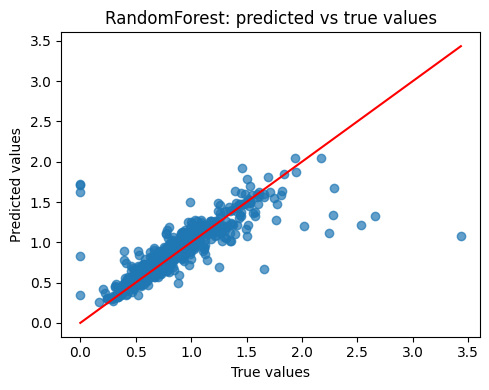

In [ ]:
best_model_name = test_results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

y_pred = best_model.predict(X_test)

make_prediction_plot(
    y_test,
    y_pred,
    title=f"{best_model_name}: predicted vs true values",
    savepath="../results/prediction_plot.png",
)

## Discussion

The results show that non-linear ensemble methods outperform the linear baseline for this problem, indicating that the relationship between descriptors and refractive index is not purely linear. Among the tested models, gradient-boosting-based methods provide the best overall performance in this study.

This suggests that relatively standard machine learning models can capture useful structure–property trends when paired with domain-specific descriptors in materials datasets.